In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import scipy.stats as stats

#import preprocessing functions
from src.preprocessing import preprocess

#import linear regression/lasso specific functions
from src.linear_regression import train_linear, test_linear, train_lasso, test_lasso

### This notebook will use basic linear regression, followed by lasso linear regression, to use as a baseline for comparison with more advanced models

In [2]:
# -- Raw training data
clean_train = preprocess(pd.read_csv("../data/raw/train_raw.csv"))
clean_train.to_csv('clean_train.csv')

# -- Raw testing data
clean_test = preprocess(pd.read_csv("../data/raw/test_raw.csv"))
clean_test.to_csv('clean_test.csv')

KeyboardInterrupt: 

In [2]:
# -- Load Training and Testing Dataframes
clean_train = pd.read_csv('clean_train.csv',index_col=0,low_memory=False)
clean_test = pd.read_csv('clean_test.csv',index_col=0,low_memory=False)

#### Linear Regression

In [3]:
# --Defining targets and model/scores dictionaries
training_features = ['MolWt', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'LogP'] + \
                    [col for col in clean_train.columns if col.startswith('fps_')]
targets = []
for col in clean_train.columns:
    if col in training_features:
        continue
    elif 'fps' in col: 
        continue
    elif col.startswith('log_'):
        targets.append(col)
    elif clean_train[col].dtype in ['float64', 'int64']:
        # Only add raw column if no log version exists
        log_version = f'log_{col}'
        if log_version not in clean_train.columns:
            targets.append(col)
            
lin_reg_models = {}
lin_reg_scores = {}
lin_reg_data = {}

In [5]:
# -- Linear Regression
for target in targets:
    model, scores, X, y, y_pred_cv = train_linear(clean_train, target)
    lin_reg_models[target] = model
    lin_reg_scores[target] = scores
    lin_reg_data[target] = (X, y, y_pred_cv)

In [12]:
for target, model in lin_reg_models.items():
    print(f"\n--- Summary for: {target} ---")
    
    summary_df = pd.DataFrame({
        'Feature': model.feature_names_in_,
        'Coefficient': model.coef_
    }).assign(Abs_Coef=lambda x: x['Coefficient'].abs())\
      .sort_values('Abs_Coef', ascending=False)\
      .drop(columns='Abs_Coef')\
      .head(15)
    
    print(summary_df.to_string(index=False))
    print(f"Intercept: {model.intercept_:.4f}")
    
    mean_score = lin_reg_scores[target].mean()
    print(f"Mean CV R2: {mean_score:.4f}")


--- Summary for: LogD ---
Feature  Coefficient
fps_132    -1.561845
fps_949     1.237875
fps_229     1.207810
fps_996     0.862132
fps_450    -0.787921
fps_492    -0.778097
fps_550     0.749587
   LogP     0.724401
 fps_44    -0.719106
fps_185     0.688114
fps_979    -0.666608
fps_284    -0.636764
fps_321    -0.634968
  fps_5     0.632602
fps_789    -0.632178
Intercept: 0.4407
Mean CV R2: 0.4911

--- Summary for: KSOL ---
Feature  Coefficient
fps_467  -124.731856
fps_229  -113.492860
fps_132   104.399488
fps_154  -101.228360
 fps_28    99.365622
fps_485   -88.546604
fps_414    86.796413
fps_462   -84.139977
fps_205   -82.995356
fps_939    80.812404
 fps_49   -79.496582
  fps_5   -77.411065
fps_517    77.206028
fps_979    72.497107
fps_313    71.043421
Intercept: 345.6025
Mean CV R2: -0.2632

--- Summary for: log_HLM CLint ---
Feature  Coefficient
fps_849     1.655444
fps_949    -1.604954
fps_814    -1.286912
fps_644     1.213751
fps_505    -1.182943
 fps_48    -1.129393
fps_519     1.

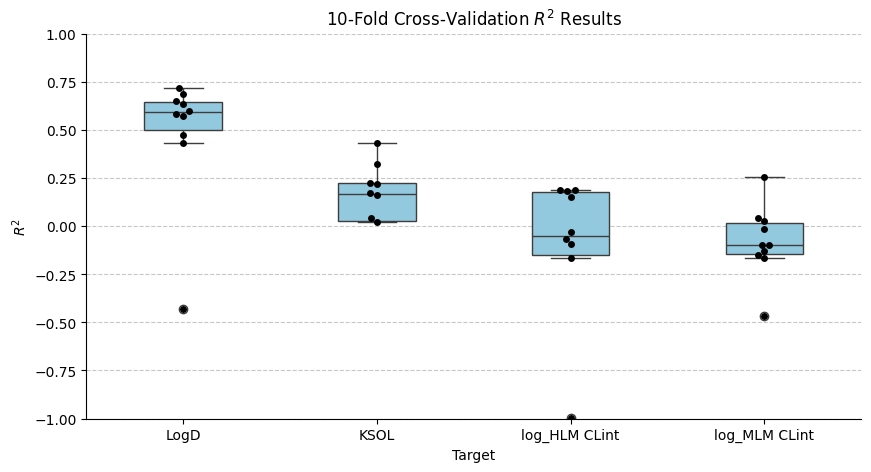

In [7]:
scores_df = pd.DataFrame(lin_reg_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results')
plt.ylabel(r'$R^2$')
plt.ylim(-1,1)
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

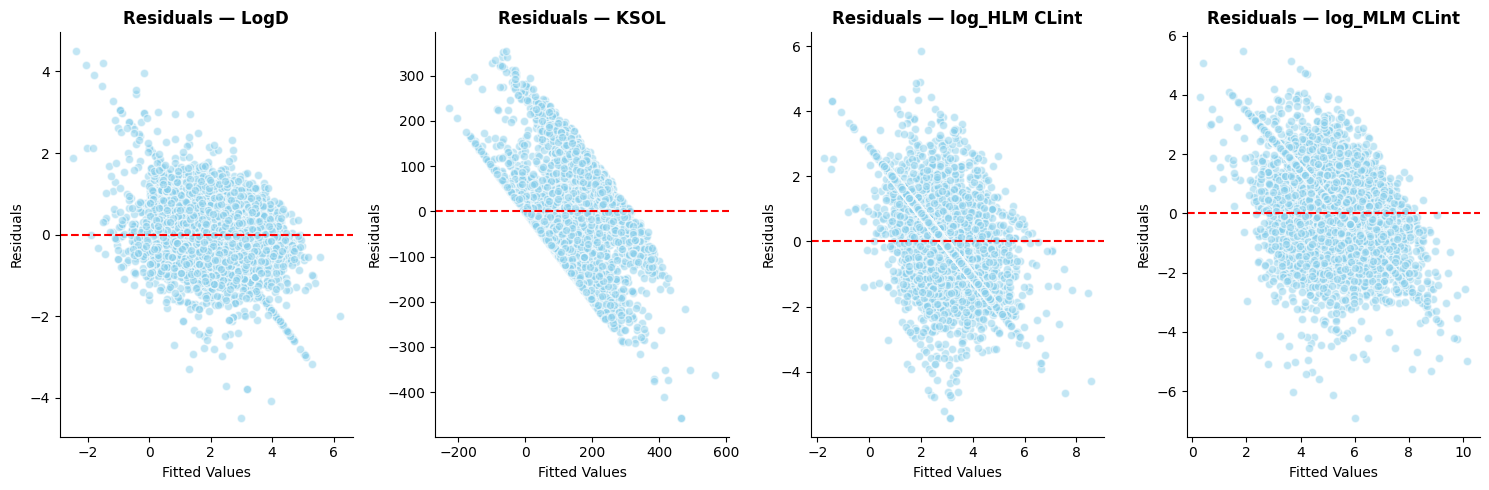

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes_flat = axes.flatten()

for ax, (target, model) in zip(axes_flat, lin_reg_models.items()):
    X, y, y_pred_cv = lin_reg_data[target]
    residuals = y - y_pred_cv
    ax.scatter(y_pred_cv, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Basic linear regression residuals show some heteroskedasticity for some endpoints, suggesting the models fail to capture non-linear relationships.

In [9]:
lin_reg_pred = {} #dictionary to hold the predictions from each model
lin_reg_resid = {} #dictionary to hold the residuals for later convience
for target in lin_reg_models.keys():
    #predict each target using its respective trained linear regression model and store results in the lin_reg_pred dictionary
    lin_reg_pred[target] = test_linear(clean_test,  lin_reg_models[target])

    residuals = lin_reg_pred[target] - clean_test[target] #calcualte residuals
    lin_reg_resid[target] = residuals #store resids

############################################################
LogD Evaluation Table
       MSE      RMSE       MAE        R2
0  0.40146  0.633609  0.432623  0.685485
############################################################
KSOL Evaluation Table
           MSE       RMSE        MAE        R2
0  7309.594644  85.496167  65.831006  0.449191
############################################################
log_HLM CLint Evaluation Table
        MSE      RMSE       MAE        R2
0  0.885702  0.941118  0.705654  0.292279
############################################################
log_MLM CLint Evaluation Table
       MSE      RMSE       MAE        R2
0  1.32469  1.150952  0.872628  0.294814


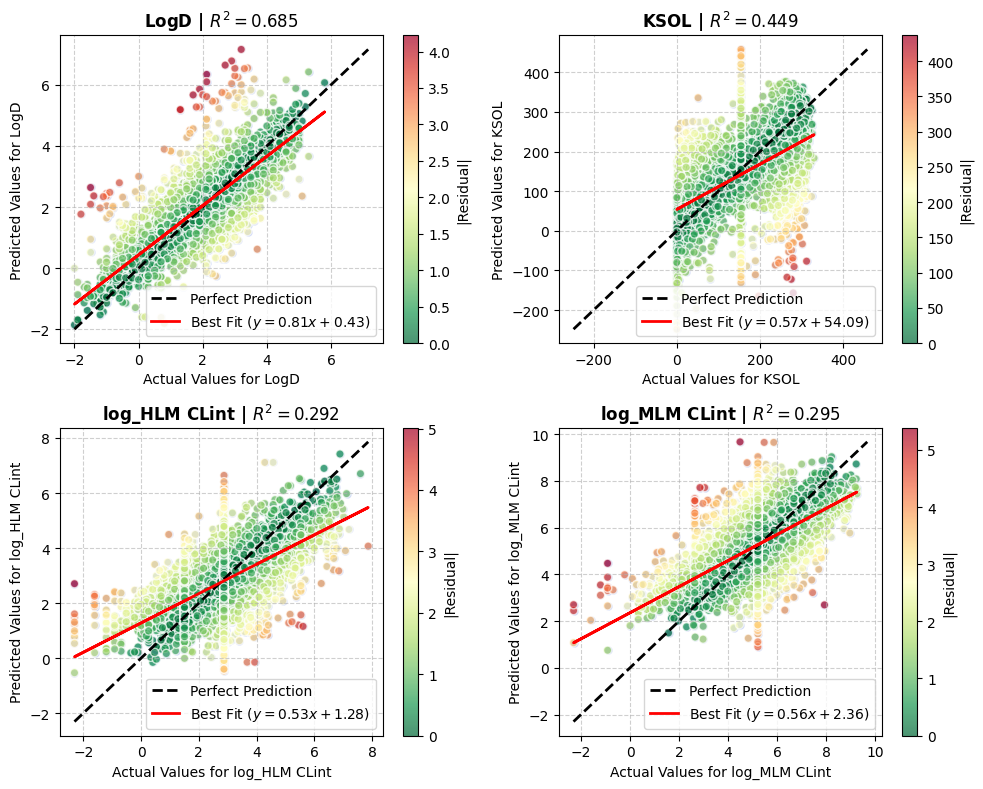

In [10]:
from src.evaluate import eval_model

# Plot test results for each model
fig, axs = plt.subplots(2, 2, figsize=(10, 8)) #Set axis
axs_flat = axs.flatten()  #flatten to use in loop

for i, target in enumerate(lin_reg_pred.keys()):
    ax = axs_flat[i]
    y_pred = lin_reg_pred[target]
    y_real = clean_test[target]
    mse, rmse, mae, r2 = eval_model(y_real, y_pred) #calculate evaluation metrics
    m, b = np.polyfit(y_real, y_pred, 1)
    ax.scatter(y_real, y_pred, alpha=0.5, color='royalblue', edgecolors='w')
    residuals = abs(lin_reg_resid[target])
    scatter = ax.scatter(y_real, y_pred, c=residuals, cmap='RdYlGn_r', #colour the residuals based on proximity to perfect prediction
                     alpha=0.7, edgecolors='w')
    plt.colorbar(scatter, ax=ax, label='|Residual|')
    min_val = min(min(y_real), min(y_pred))
    max_val = max(max(y_real), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction') #line representing perfect prediction
    ax.plot(y_real, m * y_real + b, color='red', lw=2, label=f'Best Fit ($y={m:.2f}x{b:+.2f}$)') #line of best fit

    ax.set_xlabel(f'Actual Values for {target}')
    ax.set_ylabel(f'Predicted Values for {target}')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title(f'{target} | $R^2 = {r2:.3f}$', fontsize=12, fontweight='bold')
    ax.legend()

    ##########Build Evaluation Table###########
    evaluation_results = {'MSE' : mse,
                          'RMSE': rmse,
                          'MAE' : mae,
                          'R2'  : r2 }
    eval_table = pd.DataFrame(evaluation_results,index=[0])
    print('#'*60)
    print(f'{target} Evaluation Table')
    print(eval_table)

plt.tight_layout()
plt.show()

There is clearly a relationship being captured in the datas, however it is not a strong fit as inciated by low R2 values. LogD seems to be the most promising, likely due to LogP being a training feature.

# Lasso Regression

In [ ]:
lasso_reg_models = {}
lasso_reg_scores = {}
lasso_reg_data = {}

In [ ]:
# -- Lasso Regression
for target in targets:
    model, scores, X, y, y_pred_cv = train_lasso(clean_train, target, training_features)
    lasso_reg_models[target] = model
    lasso_reg_scores[target] = scores
    lasso_reg_data[target] = (X, y, y_pred_cv)

KeyboardInterrupt: 

In [ ]:
# Iterate through both the target name and the model object
for target, model in lasso_reg_models.items():
    print(f"\n--- Summary for: {target} ---")
    
    lasso_step = model.named_steps['lasso']
    feature_names = model.named_steps['scaler'].feature_names_in_
    
    summary_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': lasso_step.coef_
    })
    
    print(summary_df.to_string(index=False))
    print(f"Intercept: {lasso_step.intercept_:.4f}")
    print(f"Optimal Alpha: {lasso_step.alpha_:.4f}")
    
    mean_score = lasso_reg_scores[target].mean()
    print(f"Mean CV R²: {mean_score:.4f}")


--- Summary for: LogD ---
      Feature  Coefficient
         KSOL    -0.530859
log_HLM CLint     0.184329
log_MLM CLint     0.300301
Intercept: 2.1184
Optimal Alpha: 0.0006
Mean CV R²: 0.3147

--- Summary for: KSOL ---
      Feature  Coefficient
         LogD   -62.640387
log_HLM CLint    -8.292354
log_MLM CLint     8.590457
Intercept: 143.3206
Optimal Alpha: 0.3119
Mean CV R²: -0.1120

--- Summary for: log_HLM CLint ---
      Feature  Coefficient
         LogD     0.234044
         KSOL    -0.085414
log_MLM CLint     0.481932
Intercept: 2.8806
Optimal Alpha: 0.0152
Mean CV R²: -1.2944

--- Summary for: log_MLM CLint ---
      Feature  Coefficient
         LogD     0.466426
         KSOL     0.120682
log_HLM CLint     0.592848
Intercept: 5.3094
Optimal Alpha: 0.0008
Mean CV R²: 0.1402


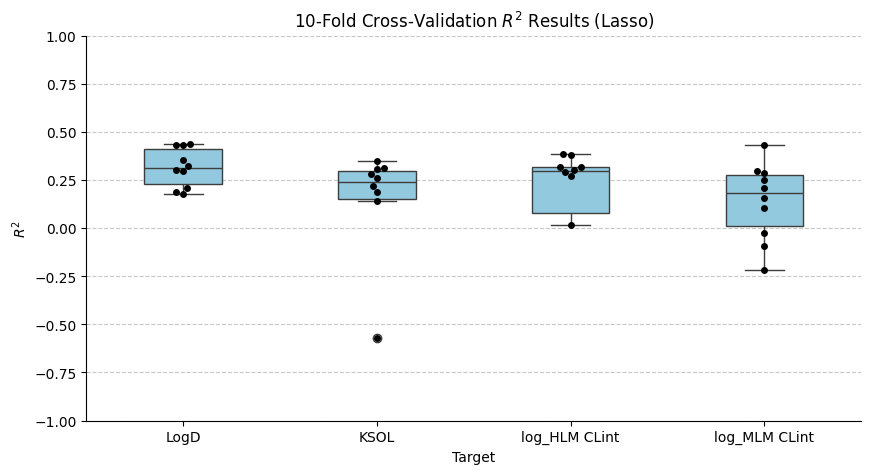

In [ ]:
scores_df_lasso = pd.DataFrame(lasso_reg_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df_lasso, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df_lasso, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results (Lasso)')
plt.ylabel(r'$R^2$')
plt.ylim(-1,1)
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

No meaningful differences in CV results compared to standard Lin Reg.

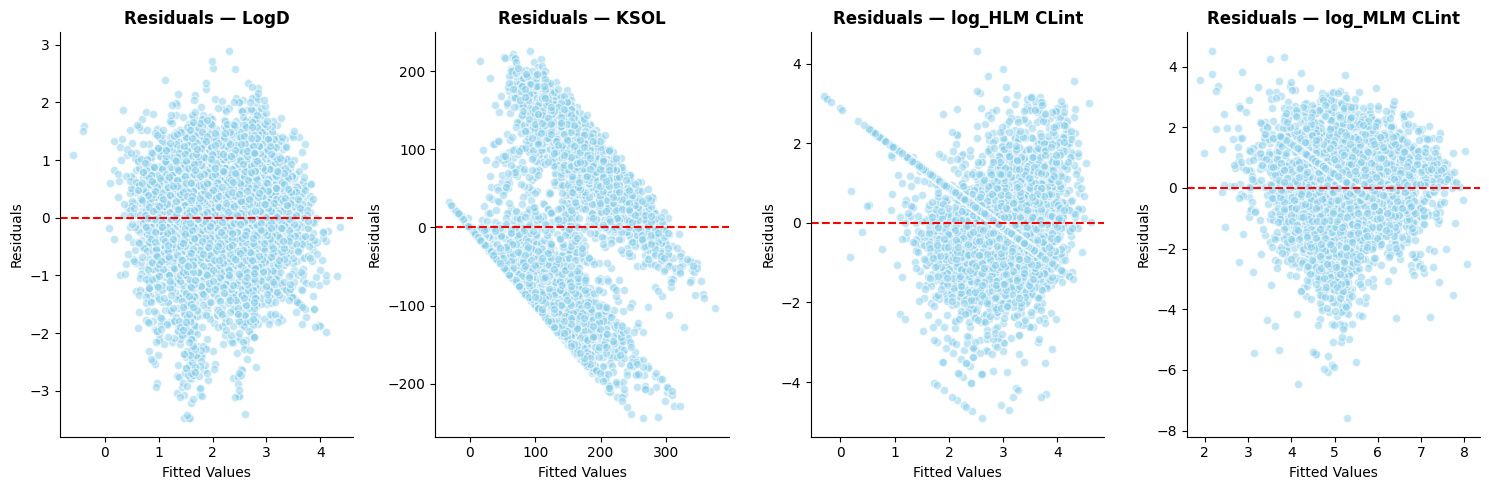

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (target, model) in zip(axes, lasso_reg_models.items()):
    X, y, y_pred_cv = lasso_reg_data[target]
    residuals = y - y_pred_cv
    ax.scatter(y_pred_cv, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Same heteroskedasticity 

In [ ]:
lasso_reg_pred = {} #dictionary to hold the predictions from each model
lasso_reg_resid = {} #dictionary to hold the residuals for later convience
for target in lasso_reg_models.keys():
    #predict each target using its respective trained lasso regression model and store results in the lasso_reg_pred dictionary
    lasso_reg_pred[target] = test_lasso(clean_test,training_features, lasso_reg_models[target])

    residuals = lasso_reg_pred[target] - clean_test[target] #calcualte residuals
    lasso_reg_resid[target] = residuals #store resids

LogD | $R^2 = 0.401$
KSOL | $R^2 = 0.284$
log_HLM CLint | $R^2 = 0.277$
log_MLM CLint | $R^2 = 0.279$


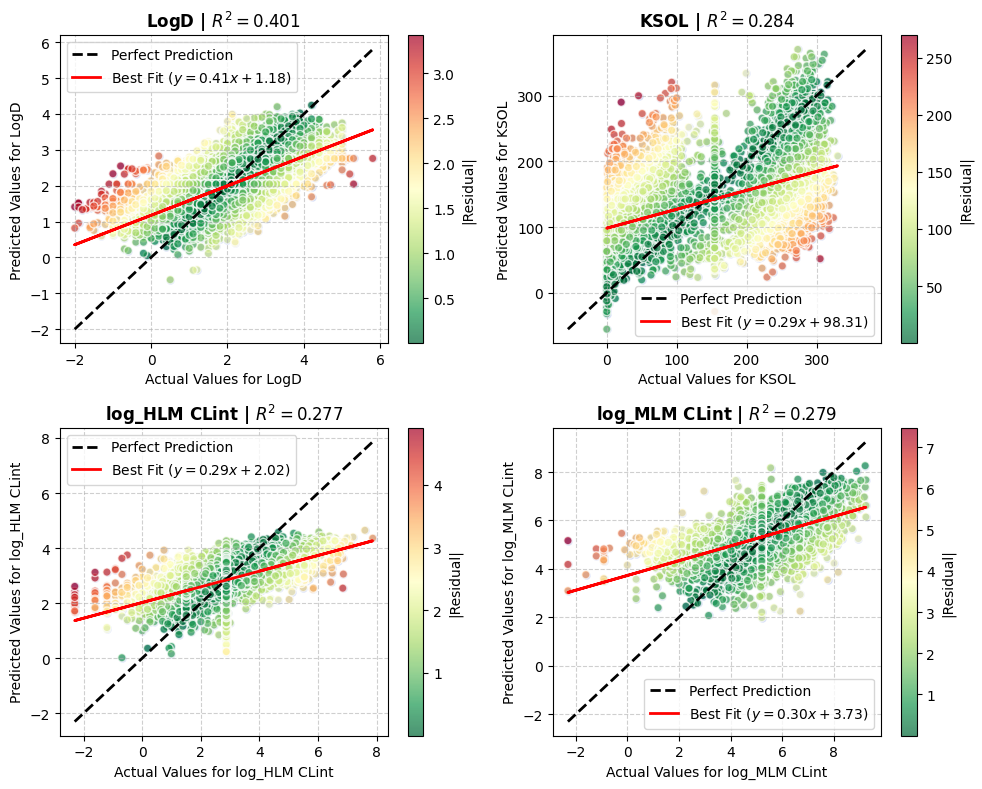

In [ ]:
# Plot test results for each Lasso model
fig, axs = plt.subplots(2, 2, figsize=(10, 8)) #Set axis
axs_flat = axs.flatten()  #flatten to use in loop

for i, target in enumerate(lasso_reg_pred.keys()):
    ax = axs_flat[i]
    y_pred = lasso_reg_pred[target]
    y_real = clean_test[target]
    r2 = r2_score(y_real, y_pred) #calculate r2
    m, b = np.polyfit(y_real, y_pred, 1)
    ax.scatter(y_real, y_pred, alpha=0.5, color='royalblue', edgecolors='w')
    residuals = abs(lasso_reg_resid[target])
    scatter = ax.scatter(y_real, y_pred, c=residuals, cmap='RdYlGn_r', #colour the residuals based on proximity to perfect prediction
                     alpha=0.7, edgecolors='w')
    plt.colorbar(scatter, ax=ax, label='|Residual|')
    min_val = min(min(y_real), min(y_pred))
    max_val = max(max(y_real), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction') #line representing perfect prediction
    ax.plot(y_real, m * y_real + b, color='red', lw=2, label=f'Best Fit ($y={m:.2f}x{b:+.2f}$)') #line of best fit

    ax.set_xlabel(f'Actual Values for {target}')
    ax.set_ylabel(f'Predicted Values for {target}')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    ax.set_title(f'{target} | $R^2 = {r2:.3f}$', fontsize=12, fontweight='bold')
    print(f'{target} | $R^2 = {r2:.3f}$')
plt.tight_layout()
plt.show()

Similar results, likely due to the low dimensionality of the feature dataset, where few features are genuinely redundant.

# Save Models

In [ ]:
import joblib

os.makedirs('../models', exist_ok=True)

# Save linear regression models
for target, model in lin_reg_models.items():
    joblib.dump(model, f'../models/linear_regression/lin_reg_{target}.pkl')

# Save lasso models
for target, model in lasso_reg_models.items():
    joblib.dump(model, f'../models/lasso/lasso_{target}.pkl')